In [1]:
import sys
sys.path.append("..")

import numpy as np

def ring_average(matrix, dist="chebyshev"):
    """
    基于距离的同心层平均
    """
    
    match dist:
        case "manhattan":
            distance = lambda x, y, c: abs(x - c) + abs(y - c)
        case "chebyshev":
            distance = lambda x, y, c: max(abs(x - c), abs(y - c))
    
    n = matrix.shape[0]
    if n % 2 == 0:
        raise ValueError("矩阵维度必须为奇数")
    
    result = matrix.copy().astype(float)
    center = n // 2
    max_layer = 2 * center  # 曼哈顿距离最大为 2*center（角落）
    
    for layer in range(max_layer + 1):
        indices = []
        # 收集该曼哈顿距离的所有坐标
        for i in range(n):
            for j in range(n):
                if distance(i, j, center) == layer:
                    indices.append((i, j))
        
        if indices:
            values = [matrix[i, j] for i, j in indices]
            avg = np.mean(values)
            for i, j in indices:
                result[i, j] = avg
                
    return result

In [2]:
# s = r"D:\Internship\bimsa\result\predictor_life_simple\2026-03-14_14-57-31_small_3_layer_seq_cnn__200-200-B3678_S34678\best_simple_life_SimpleCNNSmall_0.1.0.pth"
s = r"D:\Internship\bimsa\result\predictor_life_simple\2026-03-22_19-17-31_small_3_layer_seq_p4cnn__200-200-R2_C0_M1_S3-7_B5-9_NB\best_simple_life_SimpleP4CNNSmall_0.5.0-p4.pth"
# s = r"/Users/heruijie/BIMSA/result/predictor_life_simple/2026-03-16_23-02-24_small_3_layer_seq_p4cnn__200-200-B13_S012V/best_simple_life_SimpleP4CNNSmall_0.5.0-p4.pth"

In [3]:
from math import ceil
import os
import re
from collections import Counter

import numpy as np
import torch
from einops import rearrange

from dataloader import LifeGameDataset
import model_conv

# s = r"D:\Internship\bimsa\result\predictor_life_simple\2026-03-11_13-48-11_small_3_layer_seq_cnn__200-200-B345_S5\best_simple_life_SimpleCNNSmall_0.1.0.pth"

p = re.compile(r".*?\\(?P<date>\d{4}(-\d\d){2})_(\d\d-){2}\d\d_.*?__(?P<n1>\d+)-(?P<n2>\d+)-(?P<rule>.*?)\\[a-z]+_simple_life_(?P<model>.*?)_\d.*?\.pth")
# p = re.compile(r".*?/(?P<date>\d{4}(-\d\d){2})_(\d\d-){2}\d\d_.*?__(?P<n1>\d+)-(?P<n2>\d+)-(?P<rule>B\d*_S\d*V?)/[a-z]+_simple_life_(?P<model>.*?)_\d.*?\.pth")

match_dict = p.match(s).groupdict()
rule_str, model_cls = match_dict["rule"], match_dict["model"]

d = f"../datasets/200-200-{rule_str}"

print(rule_str, model_cls)

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

model = getattr(model_conv, model_cls)()
model.train()
model.load_state_dict(torch.load(s, map_location=device))
model.to(device)

all_files = [os.path.join(d, f) for f in os.listdir(d) if f.endswith('.npy')]
all_files.sort()  # Ensure deterministic split
test_files = all_files[::5]
file_list = [i for i in all_files if i not in test_files]

dataset = LifeGameDataset(file_list=file_list)
data = np.concatenate(dataset.arr_list, axis=0).reshape(-1, 1, 200, 200)

input_original_tensors = torch.tensor(data).float().requires_grad_(False)

print(input_original_tensors.shape)
input_tensors = rearrange(torch.nn.Unfold(kernel_size=(21, 21), padding=0, stride=40)(input_original_tensors),
                          "n (a b) l -> (n l) 1 a b", a=21, b=21)[:1000].detach().clone().requires_grad_(True)
print(input_tensors.shape)

out = model(input_tensors.to(device))
*_, row, col = out.shape
row, col
grad = torch.zeros_like(out)
grad[0, 0, row//2, col//2] = 1

out.backward(gradient=grad)
print(input_tensors.grad.shape)
grad_abs = torch.abs(input_tensors.grad).detach().clone()

res_max = torch.max(grad_abs.cpu(), dim=0)[0][0].numpy()
res_max[res_max.shape[0]//2, res_max.shape[0]//2] = 0

res_max = res_max / np.sum(res_max, axis=None)

R2_C0_M1_S3-7_B5-9_NB SimpleP4CNNSmall


d:\Internship\bimsa\.venv\lib\site-packages\e2cnn\nn\modules\r2_conv\basisexpansion_singleblock.py:80: UserWarning: indexing with dtype torch.uint8 is now deprecated, please use a dtype torch.bool instead. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen/native/IndexingUtils.h:38.)
  full_mask[mask] = norms.to(torch.uint8)


torch.Size([16000, 1, 200, 200])
torch.Size([1000, 1, 21, 21])
torch.Size([1000, 1, 21, 21])


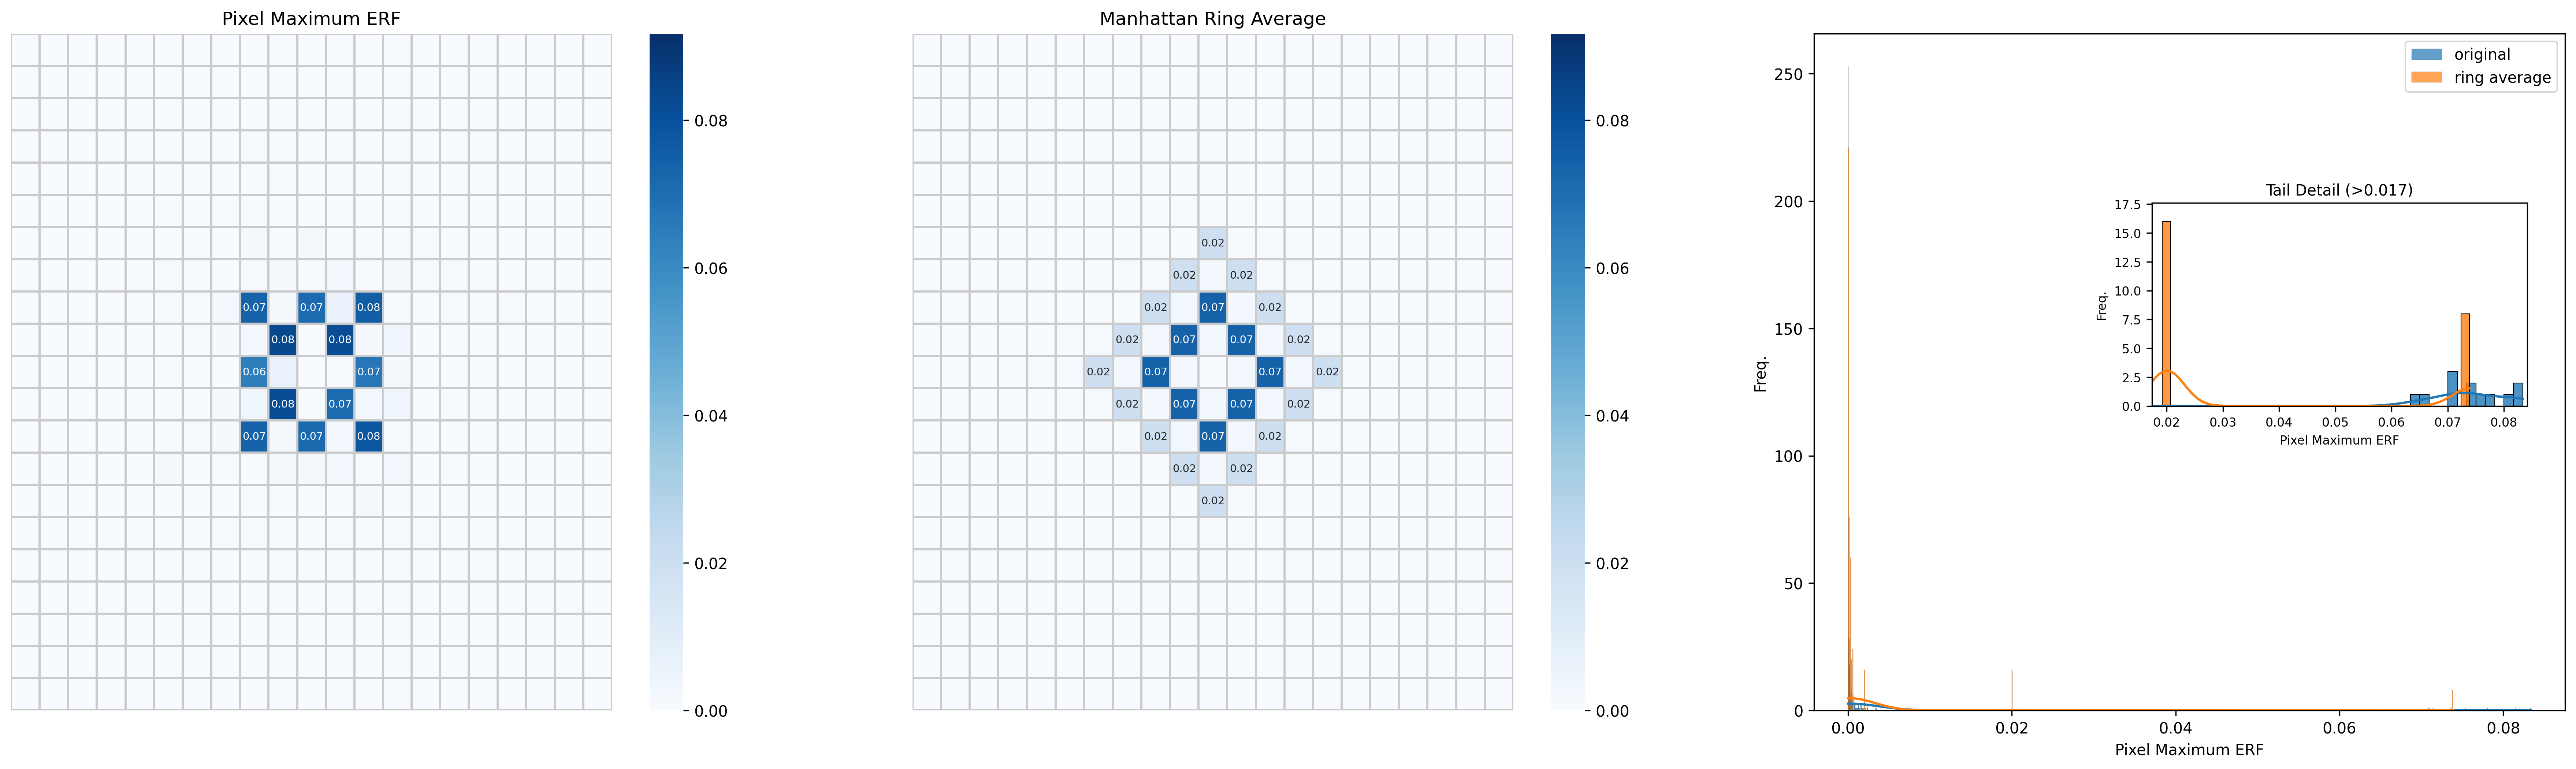

In [4]:

import matplotlib.pyplot as plt
import seaborn as sns

fig = plt.figure(figsize=(30, 8), dpi=300)
# plt.suptitle(f"Maximum Absolute Pixel Effective Respective Fields of {model.__class__.__name__}\ntrained on {rule_str.replace('_', '/')} Data ({input_tensors.shape[0]} in-distribution samples)")

ax1 = plt.subplot(1, 3, 1)
annot_matrix = np.where(res_max >= 0.01, np.round(res_max, 2), '')
vmax = res_max.max() * 1.1
ax1.set_title("Pixel Maximum ERF")
sns.heatmap(res_max, cmap="Blues", annot=annot_matrix, fmt='', vmax=vmax, vmin=0, linewidths=1, linecolor="#cbcbcb", annot_kws={"size": 7}, ax=ax1)
ax1.set_xticks([]); ax1.set_yticks([])

ax2 = plt.subplot(1, 3, 2)

if np.linalg.norm(ring_average(res_max, "manhattan")-res_max) < np.linalg.norm(ring_average(res_max, "chebyshev")-res_max):
    ring_avg = ring_average(res_max, "manhattan")
    title_str = "Manhattan Ring Average"
else:
    ring_avg = ring_average(res_max, "chebyshev")
    title_str = "Chebyshev Ring Average"
    
ax2.set_title(title_str)
annot_matrix = np.where(ring_avg >= 0.01, np.round(ring_avg, 2), '')
sns.heatmap(ring_avg, cmap="Blues", annot=annot_matrix, fmt='', vmax=vmax, vmin=0, linewidths=1, linecolor="#cbcbcb", annot_kws={"size": 7}, ax=ax2)
ax2.set_xticks([]); ax2.set_yticks([])

ax3 = plt.subplot(1, 3, 3)
sns.histplot(res_max.flatten(), kde=True, ax=ax3, alpha=0.7, label="original")
sns.histplot(ring_avg.flatten(), kde=True, ax=ax3, alpha=0.7, label="ring average")
ax3.set_xlabel("Pixel Maximum ERF"); ax3.set_ylabel("Freq.")
ax3.legend()

ax_inset = ax3.inset_axes([0.45, 0.45, 0.5, 0.3])  # 右上角位置

# 绘制相同数据的局部放大（右侧长尾）
sns.histplot(res_max.flatten(), kde=True, ax=ax_inset, 
             alpha=0.8, bins=50, edgecolor='black', linewidth=0.5)
sns.histplot(ring_avg.flatten(), kde=True, ax=ax_inset, 
             alpha=0.8, bins=50, edgecolor='black', linewidth=0.5)

# 设置放大范围：根据你的数据调整这两个阈值
th = res_max.max()*0.2 + res_max.mean() * 0.3
ax_inset.set_xlim(th, res_max.max()*1.01)  # 只看大于threshold的部分
ax_inset.set_ylim(0, 
                  max(5, 
                      Counter(np.concatenate((res_max[res_max > th].flatten(), 
                                              ring_avg[ring_avg > th].flatten()))
                              ).most_common(1)[0][1]) * 1.1)  # 根据实际低频区域调整y轴上限

# 子图美化
ax_inset.set_title(f'Tail Detail (>{th:.2g})', fontsize=10, pad=5)
ax_inset.set_xlabel('Pixel Maximum ERF', fontsize=8)
ax_inset.set_ylabel('Freq.', fontsize=8)
ax_inset.tick_params(labelsize=8)
# ax_inset.patch.set_facecolor("#d2e4ff")  # 淡红背景突出显示
# ax_inset.spines['top'].set_color('darkred')
# ax_inset.spines['right'].set_color('darkred')

# 添加连接线（自动高亮主图中被放大的区域）
# ax3.indicate_inset_zoom(ax_inset, linewidth=1, alpha=0.5)

# 可选：在主图中添加半透明矩形标记被放大区域
# ax3.axvspan(threshold, res_max.max(), alpha=0.1, zorder=0)

plt.show()

fig.savefig(f"./{model.__class__.__name__}_{rule_str}.pdf", transparent=True, dpi=400, format="pdf")

In [5]:
def erf_threshold_by_energy(erf_matrix):
    
    center_point = np.zeros_like(erf_matrix)
    center_point[erf_matrix.shape[0]//2, erf_matrix.shape[1]//2] = True
    res = []
    seen = set()
    
    for target_energy in sorted(np.linspace(0, 1, 10), reverse=True):
        if target_energy < 1e-3 or target_energy > 1 - 1e-3:
            continue
        
        flat = res_max.flatten()
        sorted_indices = np.argsort(flat)[::-1]
        sorted_values = flat[sorted_indices]
        cumsum = np.cumsum(sorted_values)
        cumsum /= cumsum[-1]
        threshold_idx = np.searchsorted(cumsum, target_energy)
        threshold = sorted_values[threshold_idx]
        mask = res_max >= threshold
        
        mask = ((np.rot90(mask, 1) + np.rot90(mask, 3) + mask + np.rot90(mask, 2)) / 4 + center_point) > 0
        
        if mask.tobytes() in seen:
            continue
        else:
            seen.add(mask.tobytes())
            res.append((mask, threshold, target_energy))
    
    return res

In [6]:
res = erf_threshold_by_energy(res_max)

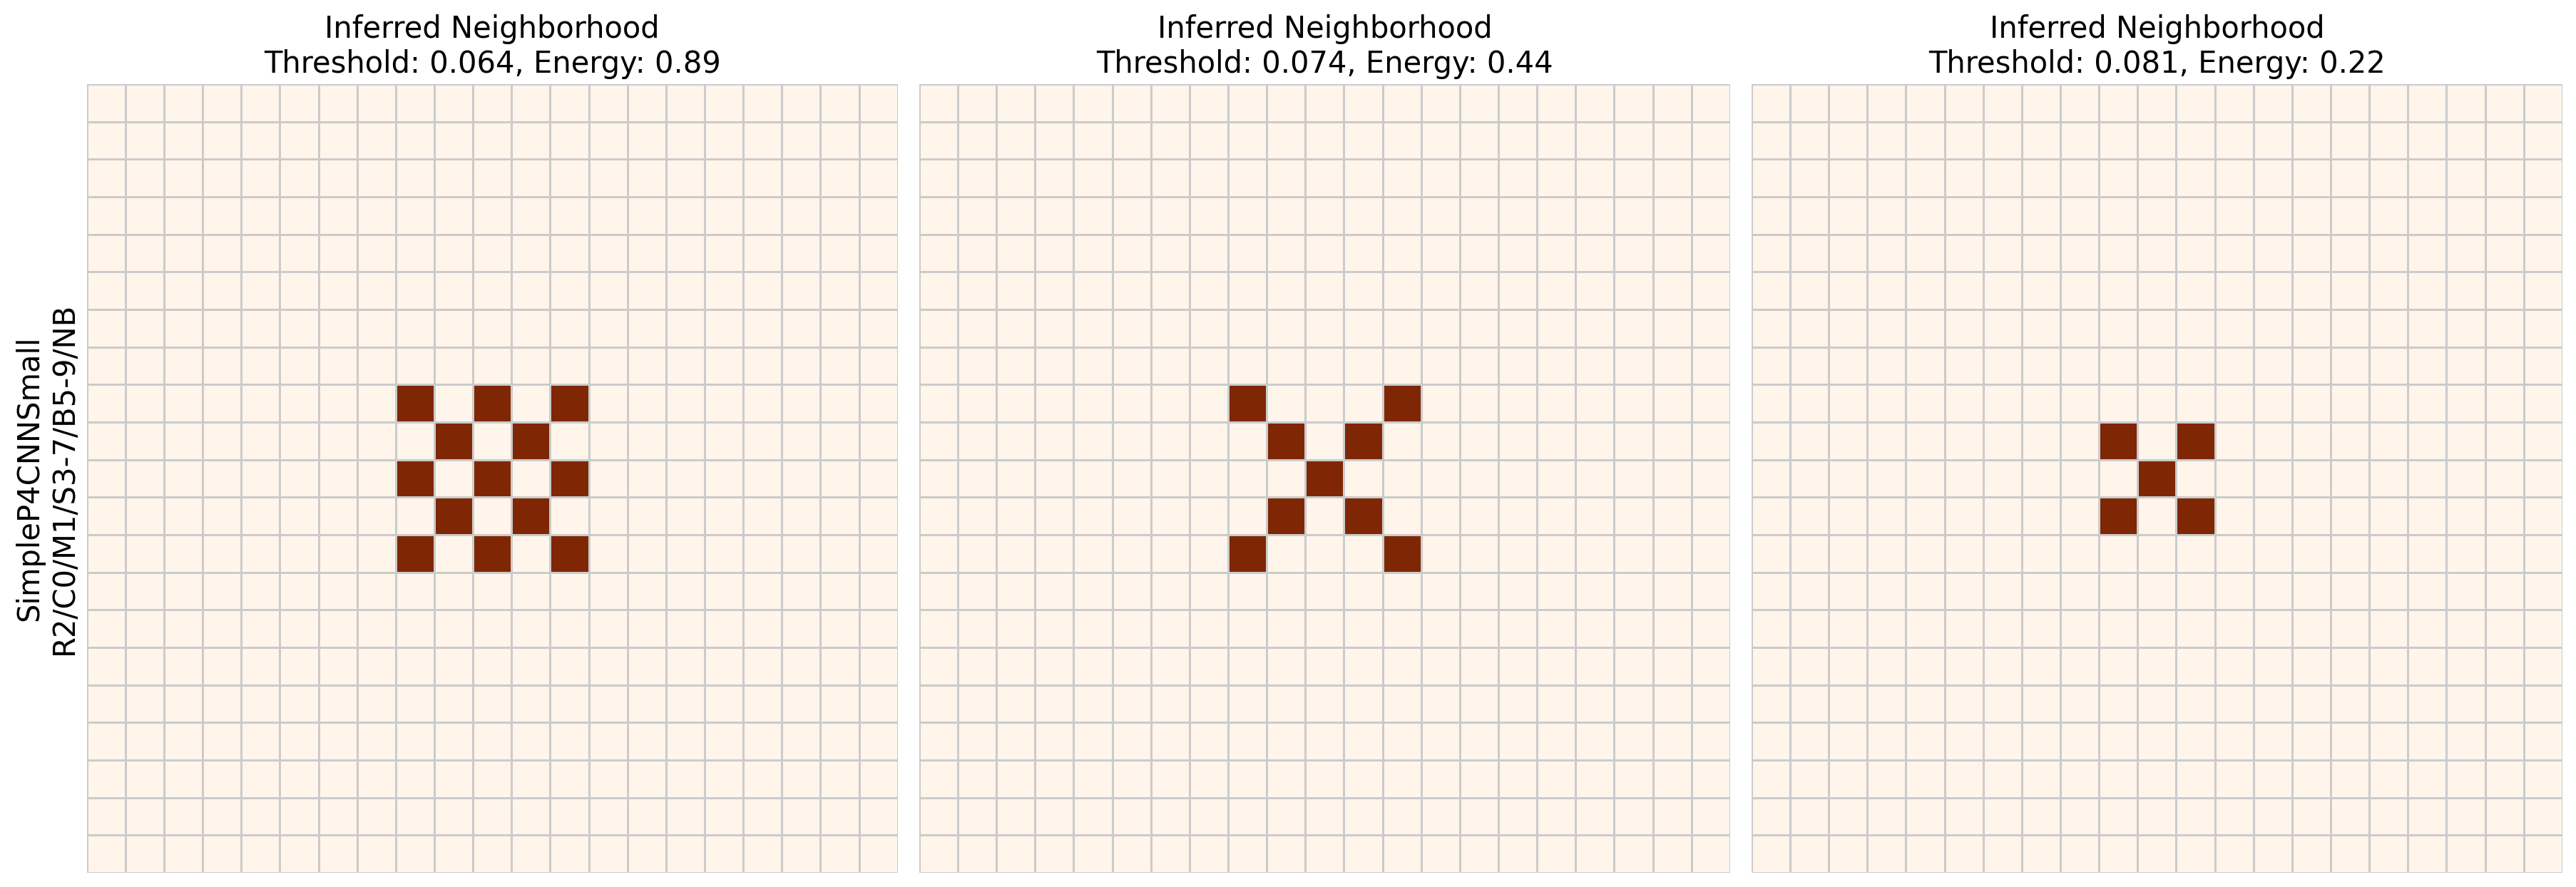

In [7]:
# plot the mask under different energy threshold

plt.figure(figsize=(24, 12), dpi=200)

for i, (mask, threshold, e) in enumerate(res):
    plt.subplot(2, 4, i+1)
    sns.heatmap(mask, cmap='Oranges', linewidths=1, linecolor="#cbcbcb", cbar=False)
    plt.title(f"Inferred Neighborhood\nThreshold: {threshold:.2g}, Energy: {e:.2g}", {'fontsize': 15})
    plt.xticks([]); plt.yticks([]);
    
    if i == 0:
        plt.ylabel(f"{model.__class__.__name__}\n{rule_str.replace('_', '/')}", rotation=90, fontdict={'fontsize': 15})

plt.tight_layout()
plt.show()

In [8]:
neighborhood = res[0][0]
w, h = neighborhood.shape

In [9]:
res[1][0]

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]])

(50, 50)
(50, 50)


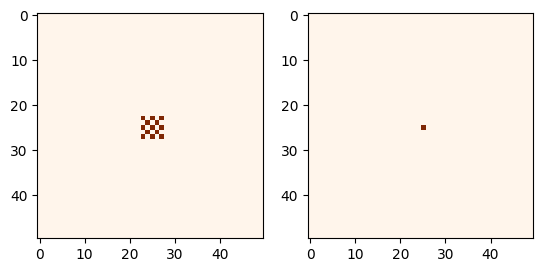

In [10]:
target_shape = (50, 50)
neighborhood_full = np.zeros(target_shape, dtype=bool)
center = target_shape[0] // 2

neighborhood_full[center-w//2:center+w//2+1, center-h//2:center+h//2+1] = neighborhood

center_point = np.zeros_like(neighborhood_full)
center_point[center, center] = True

plt.subplot(1, 2, 1)
plt.imshow(neighborhood_full, cmap="Oranges"); print(neighborhood_full.shape)
plt.subplot(1, 2, 2)
plt.imshow(center_point, cmap="Oranges"); print(center_point.shape)

In [11]:
from train_test import apply_rotation, apply_translation

apply_translation(apply_rotation(torch.from_numpy(neighborhood_full)[None, ...], 90)[0], (10, 10))

((tensor([[False, False, False,  ..., False, False, False],
          [False, False, False,  ..., False, False, False],
          [False, False, False,  ..., False, False, False],
          ...,
          [False, False, False,  ..., False, False, False],
          [False, False, False,  ..., False, False, False],
          [False, False, False,  ..., False, False, False]]),),
 (10, 10))

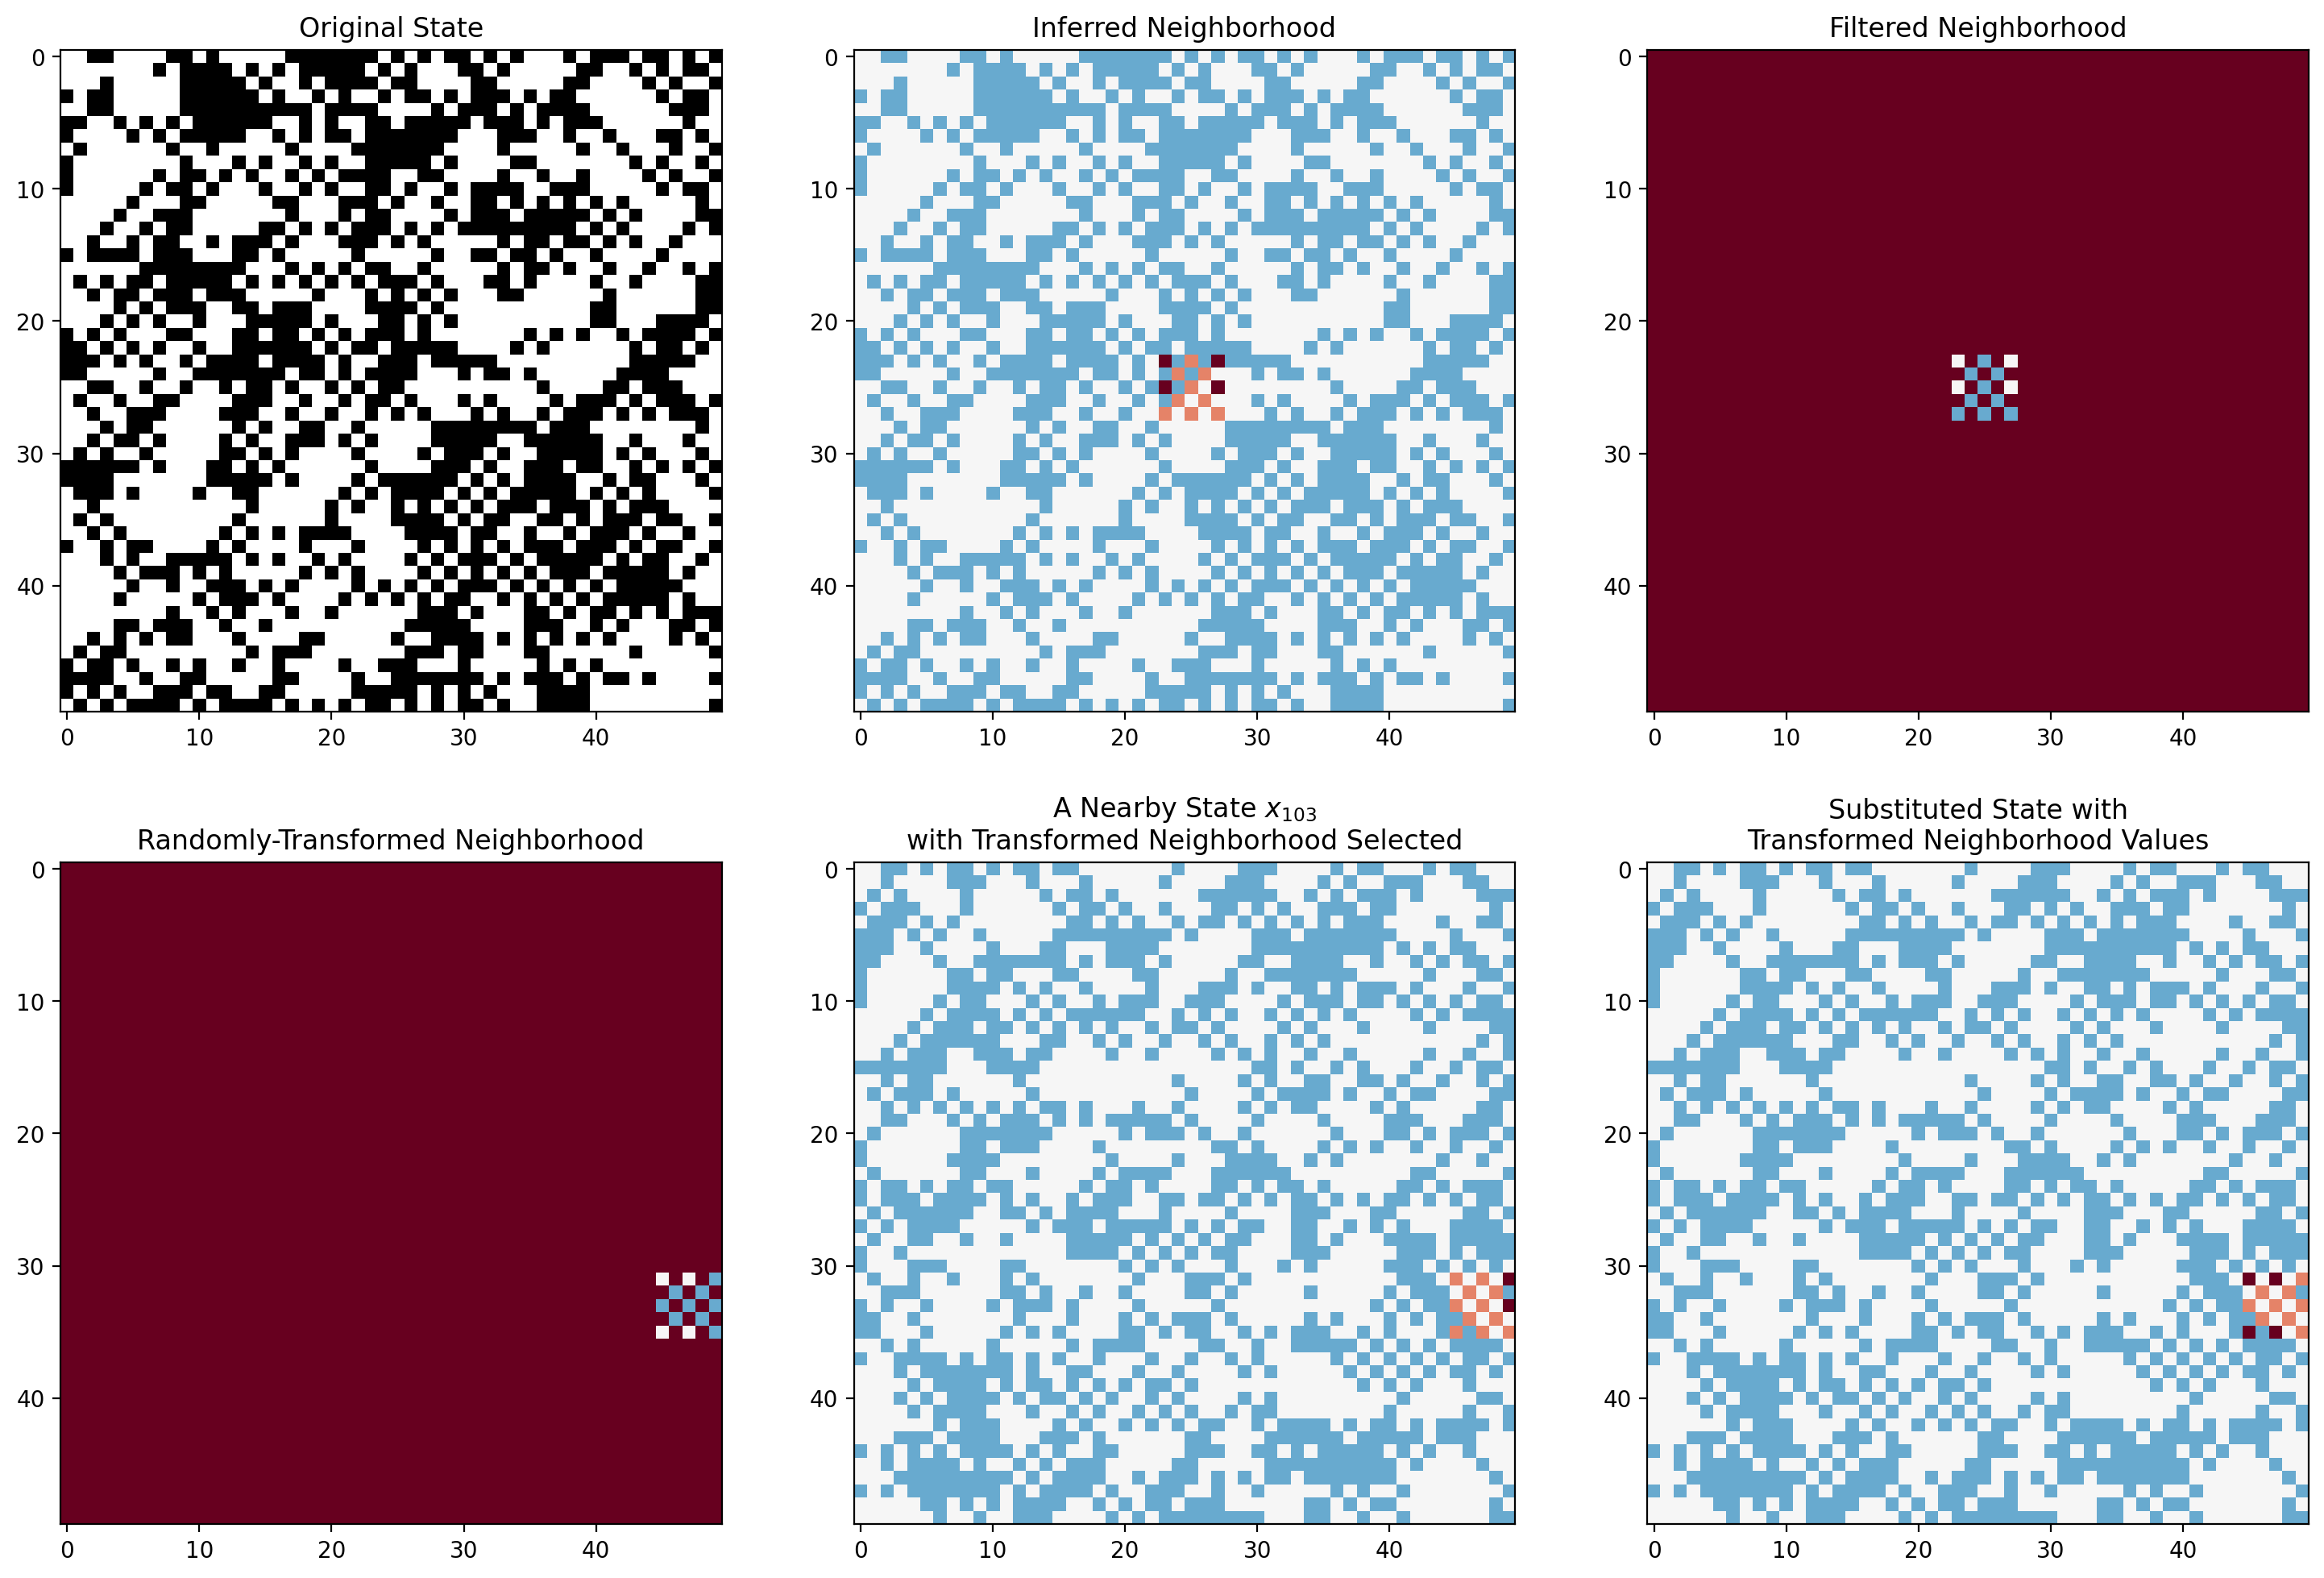

In [12]:
from copy import deepcopy

arr = deepcopy(dataset.arr_list[0][102, :50, :50])

plt.figure(figsize=(18, 12), dpi=200)

plt.subplot(2, 3, 1)
plt.title("Original State")
plt.imshow(arr, cmap="Grays")
plt.subplot(2, 3, 2)
plt.title("Inferred Neighborhood")
plt.imshow(arr - 2*neighborhood_full, cmap="RdBu", vmax=2, vmin=-2)
plt.subplot(2, 3, 3)
plt.title("Filtered Neighborhood")
filtered = deepcopy(arr).astype(float)
filtered[~neighborhood_full] = -2
plt.imshow(filtered, cmap="RdBu", vmax=2, vmin=-2)

# =============== randomly transform and 
t_neighbor, t_filtered, t_center = apply_translation(apply_rotation((
                                                torch.from_numpy(neighborhood_full)[None, ...], 
                                                torch.from_numpy(filtered)[None, ...], 
                                                torch.from_numpy(center_point)[None, ...]
                                        ))[0])[0]
t_neighbor, t_filtered, t_center = t_neighbor[0].numpy(), t_filtered[0].numpy(), t_center[0].numpy()

plt.subplot(2, 3, 4)
plt.title("Randomly-Transformed Neighborhood")
plt.imshow(t_filtered, cmap="RdBu", vmax=2, vmin=-2)

diff_ran = np.random.randint(-10, 11, size=1)
arr1_near = deepcopy(dataset.arr_list[0][100 + diff_ran[0], :50, :50])

plt.subplot(2, 3, 5)
plt.title("A Nearby State $x_{" + str(100 + diff_ran[0]) + "}$\nwith Transformed Neighborhood Selected")
plt.imshow(arr1_near - 2*t_neighbor, cmap="RdBu", vmax=2, vmin=-2)

n_filtered = deepcopy(arr1_near)
n_filtered[t_neighbor] = t_filtered[t_neighbor]
plt.subplot(2, 3, 6)
plt.title("Substituted State with\nTransformed Neighborhood Values")
plt.imshow(n_filtered - 2*t_neighbor, cmap="RdBu", vmax=2, vmin=-2)

In [13]:
res = model(torch.from_numpy(arr)[None, None, ...].float().to(device)).detach().cpu().numpy()[0][0]
res[center_point] > 0

array([ True])

In [14]:
res = model(torch.from_numpy(n_filtered)[None, None, ...].float().to(device)).detach().cpu().numpy()[0][0]
res[t_center] > 0

array([ True])

In [15]:
findmax_2d = lambda x: np.where(x == x.max())

In [16]:
res

array([[  2.2431,  -6.5013,   6.326 , ...,  -4.5636,  -4.3709,   1.8551],
       [ -7.7343,  11.5831,  -1.8988, ..., -10.5121,  -6.8676,  11.8969],
       [  1.1375,  15.4601,  11.4804, ..., -10.5668, -10.3542,  -1.3856],
       ...,
       [ -9.4556,  19.2117, -10.2919, ...,  -3.5636,  21.6331, -13.6433],
       [ -4.801 ,   2.7343,  19.8388, ...,  19.498 , -13.0872,  19.5628],
       [  4.1177,  12.0833,  -6.2815, ...,  -5.2794,  -4.3758, -10.3042]], dtype=float32)

In [23]:
from collections import Counter
from scipy.stats import fisher_exact, binomtest
from tqdm import tqdm
from statsmodels.stats.multitest import multipletests
res = erf_threshold_by_energy(res_max)

ll = []
n_num = 400
patch_num = 20

for n in res[::-1]:
    neighborhood = n[0]
    
    print(neighborhood.astype(int))
    p_value_list = []
    
    torch.cuda.empty_cache()
    
    for _ in tqdm(range(n_num)):
        traj_index = np.random.randint(0, len(dataset.arr_list)-1)
        traj = dataset.arr_list[traj_index]
        slice_index = np.random.randint(0, len(traj)-1)
        arr = traj[slice_index].copy()

        target_shape = arr.shape
        neighborhood_full = np.zeros(target_shape, dtype=bool)
        center = target_shape[0] // 2
        neighborhood_full[center-w//2:center+w//2+1, center-h//2:center+h//2+1] = neighborhood
        center_point = np.zeros_like(neighborhood_full)
        center_point[center, center] = True

        filtered = arr.copy().astype(float)
        filtered[~neighborhood_full] = -2

        # =============== randomly transform and

        # print(filtered[filtered > -2], end=' --> ')
        original_output = model(torch.from_numpy(arr)[None, None, ...].float().to(device)).detach().cpu().numpy()[0][0][center_point] > 0
        # print(original_output, end='\t')

        n_filters = []
        n_centers = []
        for _ in range(patch_num):
            t_neighbor, t_filtered, t_center = apply_translation(apply_rotation((
                                                            torch.from_numpy(neighborhood_full)[None, ...], 
                                                            torch.from_numpy(filtered)[None, ...], 
                                                            torch.from_numpy(center_point)[None, ...]
                                                    ))[0])[0]
            t_neighbor, t_filtered, t_center = t_neighbor[0].numpy(), t_filtered[0].numpy(), t_center[0].numpy()

            near_index = np.random.randint(0, len(traj)-1)
            arr1_near = np.squeeze((traj[near_index].copy()))

            n_filtered = arr1_near.copy()
            
            n_filtered[t_neighbor] = t_filtered[t_neighbor]
            
            n_filters.append(n_filtered)
            n_centers.append(t_center)
        
        n_filters = torch.from_numpy(np.stack(n_filters))[:, None, ...].float()
        n_centers = torch.from_numpy(np.stack(n_centers))[:, None, ...]
        
        # [100, 200, 200]
        res_s = Counter((torch.sum(model(n_filters.to(device))[:, :1] * n_centers.to(device), dim=[1, 2, 3]) > 0).detach().cpu().numpy())
        
        test_result = None
            
        original_true = 1 if original_output else 0
        original_false = 1 - original_true
        n_true_interv = res_s[True] 
        n_false_interv = res_s[False] 
        
        table = [[original_true, original_false],
                [n_true_interv, n_false_interv]]
        
        odds_ratio, p_value = fisher_exact(table, alternative="two-sided")

        test_result = p_value
        
        p_value_list.append(test_result)
        # print(round(test_result, 3), res_s.most_common(1)[0][0], res_s, sep='\t')

    reject_all = np.sum(np.array(p_value_list) < 0.05)
    ll.append(p_value_list)
    print(np.array(p_value_list).mean(), reject_all)

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


100%|██████████| 400/400 [00:24<00:00, 16.23it/s]


0.8153571428571428 0
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


100%|██████████| 400/400 [00:24<00:00, 16.54it/s]


0.9053571428571427 2
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


100%|██████████| 400/400 [00:23<00:00, 16.94it/s]

1.0 0


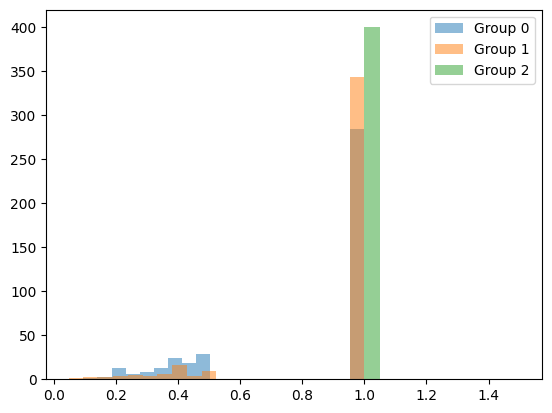

: 

In [ ]:
for i, l in enumerate(ll):
    plt.hist(l, alpha=0.5, label=f"Group {i}", bins=20)

plt.legend()